In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
ruta_archivo = '/content/drive/MyDrive/MOE_DGA/train_1M.csv'  # Reemplaza con la ruta real

df = pd.read_csv(ruta_archivo)

print(df)

                                         domain   family  label
0                               newmedialove.ru    legit  legit
1                                   bankesb.com    legit  legit
2                         sbjnvufhillsszger.net   fobber    dga
3                                  rpltm.online    legit  legit
4                               theblotsays.com    legit  legit
...                                         ...      ...    ...
1079995  c487bd0ebaf628e49016b23579812685.co.cc  bamital    dga
1079996   c21377bf084803b5d03161903bc5f643.info  bamital    dga
1079997                              yuncai.ltd    legit  legit
1079998                          movingscam.com    legit  legit
1079999                            aqaebif.info   pykspa    dga

[1080000 rows x 3 columns]


In [ ]:
# Assuming the dataframe is already loaded and named 'df'
family_counts = df['family'].value_counts()
df = df.rename(columns={'label': 'Labels'})
print(family_counts)

family
legit            540000
fobber            10000
mydoom            10000
pushdo            10000
tinba             10000
ramdo             10000
kraken            10000
monerominer       10000
sisron            10000
emotet            10000
deception         10000
rovnix            10000
qsnatch           10000
locky             10000
dircrypt          10000
corebot           10000
bedep             10000
simda             10000
manuelita         10000
shiotob           10000
alureon           10000
pitou             10000
proslikefan       10000
gameover          10000
cryptolocker      10000
dyre              10000
murofetweekly     10000
charbot           10000
suppobox          10000
padcrypt          10000
vidro             10000
oderoor           10000
vawtrak           10000
bamital           10000
nymaim            10000
necurs            10000
zeus-newgoz       10000
ranbyus           10000
qadars            10000
tinynuke          10000
matsnu            10000
pykspa   

In [ ]:
# Instalación de bibliotecas necesarias
%%capture
!pip install transformers datasets evaluate


In [ ]:
# DIAGNÓSTICO RÁPIDO - Ejecuta esto primero
print("🔍 REVISANDO DATASET:")
print(f"Forma del dataset: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print(f"Tipos de datos:\n{df.dtypes}")

if 'Labels' in df.columns:
    print(f"\nDistribución de Labels:")
    print(df['Labels'].value_counts())
    print(f"\nValores únicos en Labels: {df['Labels'].unique()}")
else:
    print("❌ No se encontró columna 'Labels'")
    print("Columnas disponibles:", list(df.columns))

# Verificar si hay valores nulos
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

# Mostrar primeras filas
print(f"\nPrimeras 5 filas:")
print(df.head())

🔍 REVISANDO DATASET:
Forma del dataset: (1080000, 3)
Columnas: ['domain', 'family', 'Labels']
Tipos de datos:
domain    object
family    object
Labels    object
dtype: object

Distribución de Labels:
Labels
legit    540000
dga      540000
Name: count, dtype: int64

Valores únicos en Labels: ['legit' 'dga']

Valores nulos por columna:
domain    0
family    0
Labels    0
dtype: int64

Primeras 5 filas:
                  domain  family Labels
0        newmedialove.ru   legit  legit
1            bankesb.com   legit  legit
2  sbjnvufhillsszger.net  fobber    dga
3           rpltm.online   legit  legit
4        theblotsays.com   legit  legit


🚀 GPU disponible: Tesla T4
💾 VRAM: 15.8 GB
🚀 INICIANDO ENTRENAMIENTO COMPLETO DGA DETECTOR
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Modelos se guardarán en: /content/drive/MyDrive/dga_models
Dataset original: 1080000 muestras

📊 PREPARANDO DATASET OPTIMIZADO
Dataset original: 1080000 muestras
Distribución original: {'legit': 540000, 'dga': 540000}
Dataset final: 1000000 muestras
Distribución final: {'legit': 500000, 'dga': 500000}
Train: 750000, Val: 100000, Test: 150000

🤖 CARGANDO MODELO ModernBERT


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

W0818 15:54:18.625000 969 torch/_inductor/utils.py:1137] [1/0] Not enough SMs to use max_autotune_gemm mode


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Roc Auc
1,0.088800,0.083905,0.970160,0.970163,0.975214,0.965164,0.995301
2,0.058500,0.077627,0.973760,0.973941,0.972319,0.975569,0.996070


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Roc Auc
1,0.088800,0.083905,0.970160,0.970163,0.975214,0.965164,0.995301
2,0.058500,0.077627,0.973760,0.973941,0.972319,0.975569,0.996070
3,0.031600,0.101577,0.973370,0.973484,0.974444,0.972525,0.994700


✅ Entrenamiento completado en 202.5 minutos

📊 EVALUACIÓN FINAL EN TEST SET


🎯 RESULTADOS FINALES:
------------------------------
LOSS        : 0.0762
ACCURACY    : 0.9735
F1          : 0.9735
PRECISION   : 0.9716
RECALL      : 0.9755
ROC_AUC     : 0.9962
RUNTIME     : 193.2001
SAMPLES_PER_SECOND: 776.3970
STEPS_PER_SECOND: 6.0660

💾 GUARDANDO MODELO FINAL
✅ Modelo guardado en: /content/drive/MyDrive/dga_models/modernbert_dga_final_20250818_191950
✅ Modelo 'latest' guardado en: /content/drive/MyDrive/dga_models/modernbert_dga_latest
🎯 MODELO COMPLETAMENTE GUARDADO
📁 Ubicación principal: /content/drive/MyDrive/dga_models/modernbert_dga_final_20250818_191950
📁 Ubicación latest: /content/drive/MyDrive/dga_models/modernbert_dga_latest

📊 CREANDO GRÁFICOS DE ENTRENAMIENTO


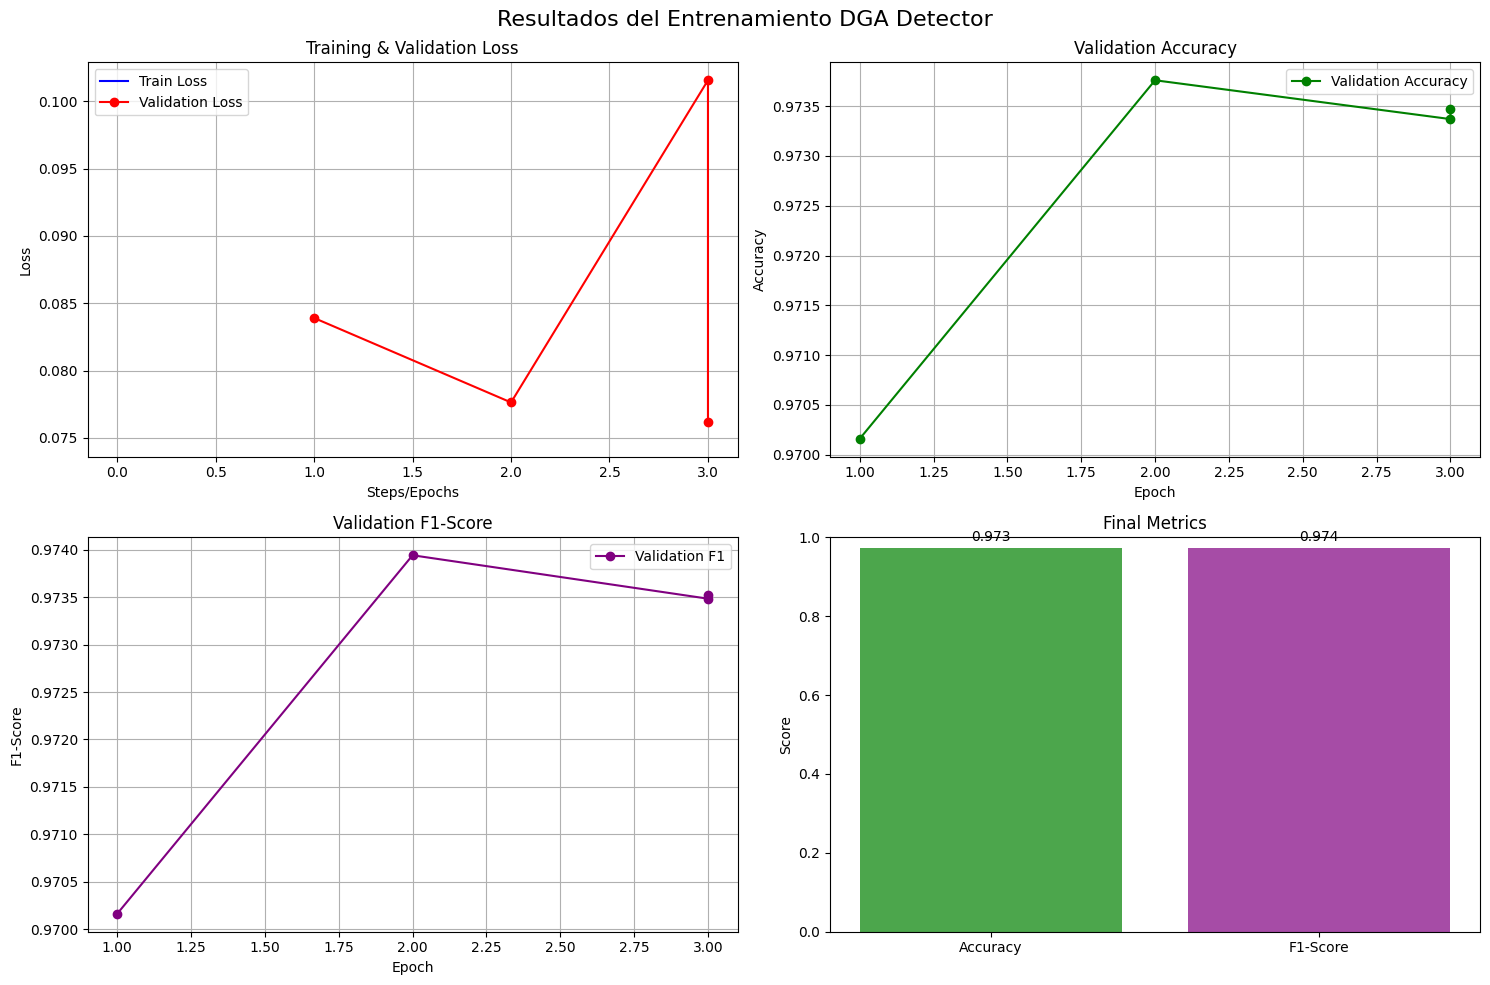

✅ Gráficos guardados en: /content/drive/MyDrive/dga_models/modernbert_dga_final_20250818_191950/training_results.png

📋 REPORTE FINAL DETALLADO

🔍 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       legit       0.98      0.97      0.97     75011
         dga       0.97      0.98      0.97     74989

    accuracy                           0.97    150000
   macro avg       0.97      0.97      0.97    150000
weighted avg       0.97      0.97      0.97    150000


🎉 ENTRENAMIENTO 100% COMPLETADO
⏱️ Tiempo total: 212.5 minutos
📁 Modelo guardado en: /content/drive/MyDrive/dga_models/modernbert_dga_latest
🎯 Test Accuracy: 0.9735
🎯 Test F1-Score: 0.9735

🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊
🏆 MODELO DGA DETECTOR COMPLETADO EXITOSAMENTE
🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊

📱 Tu modelo está listo para usar en:
   /content/drive/MyDrive/dga_models/modernbert_dga_final_20250818_191950

🚀 ¡Ya puedes detectar dominios DGA con alta precisión!


In [ ]:
# ============================================================================
# ENTRENAMIENTO DGA COMPLETO - 3 ÉPOCAS EN UNA SESIÓN
# Optimizado para máximo rendimiento en Colab
# ============================================================================

import pandas as pd
import numpy as np
import torch
import os
import json
import time
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import evaluate
from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones de optimización
os.environ["WANDB_DISABLED"] = "true"
torch.backends.cudnn.benchmark = True  # Optimizar CUDA

class DGAModelTrainer:
    """Clase principal para entrenar el modelo DGA completo"""

    def __init__(self, backup_path="/content/drive/MyDrive/dga_models"):
        self.backup_path = backup_path
        self.setup_drive()

    def setup_drive(self):
        """Montar Google Drive y crear directorios"""
        drive.mount('/content/drive')
        os.makedirs(self.backup_path, exist_ok=True)
        os.makedirs(f"{self.backup_path}/checkpoints", exist_ok=True)
        print(f"📁 Modelos se guardarán en: {self.backup_path}")

    def save_final_model(self, trainer, tokenizer, results, training_time):
        """Guardar modelo final y resultados"""
        print(f"\n💾 GUARDANDO MODELO FINAL")

        # Crear timestamp para versión única
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        model_path = f"{self.backup_path}/modernbert_dga_final_{timestamp}"

        # Guardar modelo y tokenizer
        trainer.save_model(model_path)
        tokenizer.save_pretrained(model_path)
        print(f"✅ Modelo guardado en: {model_path}")

        # Guardar también una versión "latest"
        latest_path = f"{self.backup_path}/modernbert_dga_latest"
        trainer.save_model(latest_path)
        tokenizer.save_pretrained(latest_path)
        print(f"✅ Modelo 'latest' guardado en: {latest_path}")

        # Guardar resultados y metadatos
        model_info = {
            'model_name': 'answerdotai/ModernBERT-base',
            'training_completed': True,
            'total_epochs': 3,
            'training_time_minutes': training_time / 60,
            'final_results': results,
            'timestamp': timestamp,
            'model_path': model_path,
            'latest_path': latest_path
        }

        info_file = f"{model_path}/model_info.json"
        with open(info_file, 'w') as f:
            json.dump(model_info, f, indent=2)

        # Crear README
        readme_content = f"""
# Modelo DGA Detector - ModernBERT

## Información del modelo:
- Modelo base: answerdotai/ModernBERT-base
- Entrenado: {time.strftime('%Y-%m-%d %H:%M:%S')}
- Épocas: 3
- Tiempo de entrenamiento: {training_time/60:.1f} minutos

## Resultados finales:
- Accuracy: {results.get('eval_accuracy', 'N/A'):.4f}
- F1-Score: {results.get('eval_f1', 'N/A'):.4f}
- Precision: {results.get('eval_precision', 'N/A'):.4f}
- Recall: {results.get('eval_recall', 'N/A'):.4f}

## Uso del modelo:
```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained('{latest_path}')
model = AutoModelForSequenceClassification.from_pretrained('{latest_path}')

# Predecir
domain = "example.com"
inputs = tokenizer(domain, return_tensors="pt", max_length=64, truncation=True, padding=True)
outputs = model(**inputs)
prediction = torch.softmax(outputs.logits, dim=-1)
# 0 = legit, 1 = dga
```
"""

        with open(f"{model_path}/README.md", 'w') as f:
            f.write(readme_content)

        print(f"🎯 MODELO COMPLETAMENTE GUARDADO")
        print(f"📁 Ubicación principal: {model_path}")
        print(f"📁 Ubicación latest: {latest_path}")

        return model_path, latest_path

def prepare_optimized_dataset(df, sample_size=1080000):
    """Prepara dataset optimizado y consistente"""
    print(f"\n📊 PREPARANDO DATASET OPTIMIZADO")

    # Verificar dataset
    print(f"Dataset original: {len(df)} muestras")
    print(f"Distribución original: {df['Labels'].value_counts().to_dict()}")

    # Usar seed fijo para reproducibilidad
    np.random.seed(42)

    # Tomar muestra balanceada
    if len(df) > sample_size:
        # Mantener proporción de clases
        dga_samples = df[df['Labels'] == 'dga'].sample(n=sample_size//2, random_state=42)
        legit_samples = df[df['Labels'] == 'legit'].sample(n=sample_size//2, random_state=42)
        df_sample = pd.concat([dga_samples, legit_samples]).sample(frac=1, random_state=42).reset_index(drop=True)
    else:
        df_sample = df.copy()

    print(f"Dataset final: {len(df_sample)} muestras")
    print(f"Distribución final: {df_sample['Labels'].value_counts().to_dict()}")

    # Convertir etiquetas
    df_sample['label_num'] = df_sample['Labels'].map({'legit': 0, 'dga': 1})

    # Split optimizado
    test_size = int(0.15 * len(df_sample))  # 15% para test
    val_size = int(0.10 * len(df_sample))   # 10% para validación

    # Crear splits
    test_df = df_sample.sample(n=test_size, random_state=42)
    remaining_df = df_sample[~df_sample.index.isin(test_df.index)]
    val_df = remaining_df.sample(n=val_size, random_state=42)
    train_df = remaining_df[~remaining_df.index.isin(val_df.index)]

    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

    return train_df, val_df, test_df

def create_optimized_datasets(train_df, val_df, test_df, tokenizer):
    """Crear datasets tokenizados optimizados"""
    print(f"\n🔤 TOKENIZACIÓN OPTIMIZADA")

    # Convertir a HF datasets
    train_dataset = Dataset.from_pandas(train_df).rename_column('label_num', 'labels')
    val_dataset = Dataset.from_pandas(val_df).rename_column('label_num', 'labels')
    test_dataset = Dataset.from_pandas(test_df).rename_column('label_num', 'labels')

    # Asegurar tipos correctos
    def format_labels(example):
        example['labels'] = int(example['labels'])
        return example

    train_dataset = train_dataset.map(format_labels)
    val_dataset = val_dataset.map(format_labels)
    test_dataset = test_dataset.map(format_labels)

    # Función de tokenización optimizada
    def tokenize_function(examples):
        return tokenizer(
            examples["domain"],
            padding="max_length",
            truncation=True,
            max_length=64,  # Reducido para velocidad
            return_tensors=None
        )

    # Tokenizar con paralelización
    tokenized_train = train_dataset.map(
        tokenize_function,
        batched=True,
        num_proc=2,
        remove_columns=['domain', 'Labels']
    )

    tokenized_val = val_dataset.map(
        tokenize_function,
        batched=True,
        num_proc=2,
        remove_columns=['domain', 'Labels']
    )

    tokenized_test = test_dataset.map(
        tokenize_function,
        batched=True,
        num_proc=2,
        remove_columns=['domain', 'Labels']
    )

    return tokenized_train, tokenized_val, tokenized_test

def setup_training_args():
    """Configurar argumentos de entrenamiento optimizados"""
    print(f"\n⚙️ CONFIGURACIÓN DE ENTRENAMIENTO")

    training_args = TrainingArguments(
        output_dir="./results",
        learning_rate=2e-5,  # Learning rate balanceado
        per_device_train_batch_size=96,  # Batch size optimizado
        per_device_eval_batch_size=128,
        num_train_epochs=3,  # 3 épocas completas
        weight_decay=0.01,
        warmup_ratio=0.1,
        lr_scheduler_type="cosine",  # Cosine scheduler para mejor convergencia

        # Evaluación y guardado
        eval_strategy="epoch",  # Evaluar cada época
        save_strategy="epoch",  # Guardar cada época
        save_total_limit=3,     # Mantener últimos 3 checkpoints

        # Métricas
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        # Logging
        logging_strategy="steps",
        logging_steps=100,

        # Optimizaciones
        fp16=True,
        gradient_checkpointing=True,
        dataloader_num_workers=2,

        # Otros
        report_to=None,
        seed=42,
        remove_unused_columns=True,
    )

    return training_args

def compute_comprehensive_metrics(eval_pred):
    """Métricas completas para evaluación"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=-1)

    # Métricas básicas
    accuracy = (predictions == labels).mean()

    # Importar sklearn para métricas avanzadas
    from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

    f1 = f1_score(labels, predictions, average='binary')
    precision = precision_score(labels, predictions, average='binary')
    recall = recall_score(labels, predictions, average='binary')

    # ROC AUC (necesitamos probabilidades)
    probabilities = torch.softmax(torch.tensor(eval_pred[0]), dim=-1)[:, 1].numpy()
    try:
        roc_auc = roc_auc_score(labels, probabilities)
    except:
        roc_auc = 0.0

    return {
        "accuracy": accuracy,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "roc_auc": roc_auc
    }

def plot_training_results(trainer_logs, save_path):
    """Crear gráficos de los resultados de entrenamiento"""
    print(f"\n📊 CREANDO GRÁFICOS DE ENTRENAMIENTO")

    # Extraer métricas del log
    train_loss = []
    eval_loss = []
    eval_f1 = []
    eval_accuracy = []
    epochs = []

    for log in trainer_logs:
        if 'eval_loss' in log:
            epochs.append(log.get('epoch', 0))
            eval_loss.append(log['eval_loss'])
            eval_f1.append(log.get('eval_f1', 0))
            eval_accuracy.append(log.get('eval_accuracy', 0))
        if 'train_loss' in log:
            train_loss.append(log['train_loss'])

    # Crear gráfico
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Resultados del Entrenamiento DGA Detector', fontsize=16)

    # Loss
    if train_loss and eval_loss:
        axes[0,0].plot(range(len(train_loss)), train_loss, label='Train Loss', color='blue')
        axes[0,0].plot(epochs, eval_loss, label='Validation Loss', color='red', marker='o')
        axes[0,0].set_title('Training & Validation Loss')
        axes[0,0].set_xlabel('Steps/Epochs')
        axes[0,0].set_ylabel('Loss')
        axes[0,0].legend()
        axes[0,0].grid(True)

    # Accuracy
    if eval_accuracy:
        axes[0,1].plot(epochs, eval_accuracy, label='Validation Accuracy', color='green', marker='o')
        axes[0,1].set_title('Validation Accuracy')
        axes[0,1].set_xlabel('Epoch')
        axes[0,1].set_ylabel('Accuracy')
        axes[0,1].legend()
        axes[0,1].grid(True)

    # F1 Score
    if eval_f1:
        axes[1,0].plot(epochs, eval_f1, label='Validation F1', color='purple', marker='o')
        axes[1,0].set_title('Validation F1-Score')
        axes[1,0].set_xlabel('Epoch')
        axes[1,0].set_ylabel('F1-Score')
        axes[1,0].legend()
        axes[1,0].grid(True)

    # Resumen final
    if eval_accuracy and eval_f1:
        final_acc = eval_accuracy[-1] if eval_accuracy else 0
        final_f1 = eval_f1[-1] if eval_f1 else 0
        axes[1,1].bar(['Accuracy', 'F1-Score'], [final_acc, final_f1],
                     color=['green', 'purple'], alpha=0.7)
        axes[1,1].set_title('Final Metrics')
        axes[1,1].set_ylabel('Score')
        axes[1,1].set_ylim(0, 1)

        # Añadir valores en las barras
        for i, v in enumerate([final_acc, final_f1]):
            axes[1,1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(f"{save_path}/training_results.png", dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Gráficos guardados en: {save_path}/training_results.png")

def main_complete_training():
    """Función principal para entrenamiento completo"""

    print("🚀 INICIANDO ENTRENAMIENTO COMPLETO DGA DETECTOR")
    print("=" * 70)

    start_total_time = time.time()

    # 1. Setup inicial
    trainer_manager = DGAModelTrainer()

    # 2. Preparar dataset
    print(f"Dataset original: {len(df)} muestras")
    train_df, val_df, test_df = prepare_optimized_dataset(df, sample_size=1000000)

    # 3. Setup modelo y tokenizer
    print(f"\n🤖 CARGANDO MODELO ModernBERT")
    model_name = "answerdotai/ModernBERT-base"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    print(f"✅ Modelo cargado: {model_name}")
    print(f"📊 Parámetros del modelo: {model.num_parameters():,}")

    # 4. Crear datasets tokenizados
    tokenized_train, tokenized_val, tokenized_test = create_optimized_datasets(
        train_df, val_df, test_df, tokenizer
    )

    # 5. Configurar entrenamiento
    training_args = setup_training_args()

    # 6. Crear trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        tokenizer=tokenizer,
        compute_metrics=compute_comprehensive_metrics,
    )

    # 7. Entrenar modelo completo
    print(f"\n🏃‍♂️ ENTRENANDO 3 ÉPOCAS COMPLETAS")
    print("-" * 50)

    try:
        # Entrenar
        training_start = time.time()
        train_result = trainer.train()
        training_time = time.time() - training_start

        print(f"✅ Entrenamiento completado en {training_time/60:.1f} minutos")

        # 8. Evaluación final en test set
        print(f"\n📊 EVALUACIÓN FINAL EN TEST SET")
        test_results = trainer.evaluate(tokenized_test)

        print(f"🎯 RESULTADOS FINALES:")
        print("-" * 30)
        for key, value in test_results.items():
            if key.startswith('eval_'):
                metric_name = key.replace('eval_', '').upper()
                print(f"{metric_name:12}: {value:.4f}")

        # 9. Guardar modelo final
        model_path, latest_path = trainer_manager.save_final_model(
            trainer, tokenizer, test_results, training_time
        )

        # 10. Crear gráficos de entrenamiento
        try:
            plot_training_results(trainer.state.log_history, model_path)
        except Exception as e:
            print(f"⚠️ No se pudieron crear gráficos: {e}")

        # 11. Reporte final detallado
        print(f"\n📋 REPORTE FINAL DETALLADO")
        print("=" * 50)

        # Predicciones para reporte detallado
        predictions = trainer.predict(tokenized_test)
        y_pred = np.argmax(predictions.predictions, axis=-1)
        y_true = predictions.label_ids

        # Classification report
        print("\n🔍 CLASSIFICATION REPORT:")
        print(classification_report(y_true, y_pred, target_names=['legit', 'dga']))

        # Tiempo total
        total_time = time.time() - start_total_time

        print(f"\n🎉 ENTRENAMIENTO 100% COMPLETADO")
        print("=" * 50)
        print(f"⏱️ Tiempo total: {total_time/60:.1f} minutos")
        print(f"📁 Modelo guardado en: {latest_path}")
        print(f"🎯 Test Accuracy: {test_results.get('eval_accuracy', 0):.4f}")
        print(f"🎯 Test F1-Score: {test_results.get('eval_f1', 0):.4f}")
        print("=" * 50)

        return True, model_path, test_results

    except Exception as e:
        print(f"❌ Error durante entrenamiento: {e}")
        import traceback
        traceback.print_exc()
        return False, None, None

# ============================================================================
# EJECUTAR ENTRENAMIENTO COMPLETO
# ============================================================================

if __name__ == "__main__":
    # Verificar GPU
    if torch.cuda.is_available():
        print(f"🚀 GPU disponible: {torch.cuda.get_device_name(0)}")
        print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    else:
        print("⚠️ No se detectó GPU")

    # Ejecutar entrenamiento completo
    success, model_path, results = main_complete_training()

    if success:
        print("\n" + "🎊" * 20)
        print("🏆 MODELO DGA DETECTOR COMPLETADO EXITOSAMENTE")
        print("🎊" * 20)
        print(f"\n📱 Tu modelo está listo para usar en:")
        print(f"   {model_path}")
        print(f"\n🚀 ¡Ya puedes detectar dominios DGA con alta precisión!")
    else:
        print("\n❌ Error en el entrenamiento completo. Revisar logs.")

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Cargar el modelo desde Drive
model_path = "/content/drive/MyDrive/dga_models_Seba/modernbert_dga_latest"
#model_path = "https://drive.google.com/drive/folders/1aS_Tm7FnU2Li4KXTygTUfyvcScRNsOa7?usp=drive_link"

print("🔍 Cargando modelo DGA...")
try:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.eval()  # Modo evaluación
    print("✅ Modelo cargado exitosamente!")
except Exception as e:
    print(f"❌ Error cargando modelo: {e}")
    print("📁 Verificando rutas disponibles...")
    import os
    base_path = "/content/drive/MyDrive/dga_models"
    if os.path.exists(base_path):
        print(f"Modelos disponibles en {base_path}:")
        for item in os.listdir(base_path):
            print(f"  - {item}")
    exit()

# 3. Función para predecir un dominio
def predict_domain(domain, model, tokenizer, verbose=True):
    """
    Predice si un dominio es legítimo o DGA

    Args:
        domain (str): Dominio a analizar
        model: Modelo entrenado
        tokenizer: Tokenizer
        verbose (bool): Mostrar detalles

    Returns:
        dict: Resultado de la predicción
    """

    # Tokenizar el dominio
    inputs = tokenizer(
        domain,
        return_tensors="pt",
        max_length=64,
        truncation=True,
        padding=True
    )

    # Hacer predicción
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.softmax(outputs.logits, dim=-1)

    # Interpretar resultados
    legit_prob = predictions[0][0].item()  # Probabilidad legítimo
    dga_prob = predictions[0][1].item()    # Probabilidad DGA

    predicted_class = "DGA" if dga_prob > legit_prob else "LEGÍTIMO"
    confidence = max(legit_prob, dga_prob)

    result = {
        'domain': domain,
        'prediction': predicted_class,
        'confidence': confidence,
        'legit_probability': legit_prob,
        'dga_probability': dga_prob
    }

    if verbose:
        print(f"\n🔍 Análisis del dominio: {domain}")
        print(f"📊 Predicción: {predicted_class}")
        print(f"🎯 Confianza: {confidence:.4f}")
        print(f"✅ Prob. Legítimo: {legit_prob:.4f}")
        print(f"⚠️ Prob. DGA: {dga_prob:.4f}")

        # Interpretación
        if confidence > 0.9:
            print(f"💪 Predicción MUY CONFIABLE")
        elif confidence > 0.7:
            print(f"👍 Predicción CONFIABLE")
        elif confidence > 0.6:
            print(f"⚠️ Predicción MODERADA")
        else:
            print(f"❓ Predicción INCIERTA")

    return result

# 4. Probar con dominios individuales
print("\n" + "="*60)
print("🚀 PROBANDO MODELO DGA DETECTOR")
print("="*60)

# Ejemplos de prueba
test_domains = [
    # Dominios legítimos
    "google.com",
    "facebook.com",
    "microsoft.com",
    "github.com",
    "stackoverflow.com",

    # Posibles DGA (ejemplos)
    "ajkdlajsdklajsd.com",
    "qwerty12345abcde.net",
    "randomtext987654.org",
    "asdfghjklzxcvbn.com"
]

print(f"\n🧪 Probando {len(test_domains)} dominios de ejemplo:")

results = []
for domain in test_domains:
    result = predict_domain(domain, model, tokenizer)
    results.append(result)
    print("-" * 50)

# 5. Resumen de resultados
print(f"\n📊 RESUMEN DE PREDICCIONES:")
print("=" * 60)

df_results = pd.DataFrame(results)
print(df_results[['domain', 'prediction', 'confidence']].to_string(index=False))

# Estadísticas
legit_count = sum(1 for r in results if r['prediction'] == 'LEGÍTIMO')
dga_count = sum(1 for r in results if r['prediction'] == 'DGA')
avg_confidence = np.mean([r['confidence'] for r in results])

print(f"\n📈 ESTADÍSTICAS:")
print(f"✅ Dominios legítimos detectados: {legit_count}")
print(f"⚠️ Dominios DGA detectados: {dga_count}")
print(f"🎯 Confianza promedio: {avg_confidence:.4f}")

# 6. Función para pruebas personalizadas
def test_custom_domain():
    """Función interactiva para probar dominios personalizados"""

    print(f"\n🎮 MODO PRUEBA PERSONALIZADA")
    print("Escribe 'quit' para salir")
    print("-" * 40)

    while True:
        domain = input("\n🌐 Introduce un dominio para analizar: ").strip()

        if domain.lower() in ['quit', 'exit', 'salir', '']:
            print("👋 ¡Hasta luego!")
            break

        if domain:
            try:
                predict_domain(domain, model, tokenizer)
            except Exception as e:
                print(f"❌ Error analizando '{domain}': {e}")
        else:
            print("⚠️ Por favor introduce un dominio válido")

print(f"\n🎯 ¡Modelo listo para usar!")
print(f"💡 Ejecuta test_custom_domain() para probar tus propios dominios")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 Cargando modelo DGA...
✅ Modelo cargado exitosamente!

🚀 PROBANDO MODELO DGA DETECTOR

🧪 Probando 9 dominios de ejemplo:

🔍 Análisis del dominio: google.com
📊 Predicción: LEGÍTIMO
🎯 Confianza: 1.0000
✅ Prob. Legítimo: 1.0000
⚠️ Prob. DGA: 0.0000
💪 Predicción MUY CONFIABLE
--------------------------------------------------

🔍 Análisis del dominio: facebook.com
📊 Predicción: LEGÍTIMO
🎯 Confianza: 1.0000
✅ Prob. Legítimo: 1.0000
⚠️ Prob. DGA: 0.0000
💪 Predicción MUY CONFIABLE
--------------------------------------------------

🔍 Análisis del dominio: microsoft.com
📊 Predicción: LEGÍTIMO
🎯 Confianza: 0.9998
✅ Prob. Legítimo: 0.9998
⚠️ Prob. DGA: 0.0002
💪 Predicción MUY CONFIABLE
--------------------------------------------------

🔍 Análisis del dominio: github.com
📊 Predicción: LEGÍTIMO
🎯 Confianza: 0.9999
✅ Prob. Legítimo: 0.9999
⚠️ Prob. DGA: 0.0001
💪 Predicc

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load model from Drive
model_path = "/content/drive/MyDrive/dga_models_Seba/modernbert_dga_latest"
#model_path = "https://drive.google.com/drive/folders/1aS_Tm7FnU2Li4KXTygTUfyvcScRNsOa7?usp=drive_link"

print("🔍 Loading DGA model...")
try:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.eval()  # Evaluation mode
    print("✅ Model loaded successfully!")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    print("📁 Checking available paths...")
    import os
    base_path = "/content/drive/MyDrive/dga_models"
    if os.path.exists(base_path):
        print(f"Available models in {base_path}:")
        for item in os.listdir(base_path):
            print(f"  - {item}")
    exit()

# 3. Function to predict a domain
def predict_domain(domain, model, tokenizer, verbose=True):
    """
    Predicts if a domain is legitimate or DGA

    Args:
        domain (str): Domain to analyze
        model: Trained model
        tokenizer: Tokenizer
        verbose (bool): Show details

    Returns:
        dict: Prediction result
    """

    # Tokenize the domain
    inputs = tokenizer(
        domain,
        return_tensors="pt",
        max_length=64,
        truncation=True,
        padding=True
    )

    # Make prediction
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.softmax(outputs.logits, dim=-1)

    # Interpret results
    legit_prob = predictions[0][0].item()  # Legitimate probability
    dga_prob = predictions[0][1].item()    # DGA probability

    predicted_class = "DGA" if dga_prob > legit_prob else "LEGITIMATE"
    confidence = max(legit_prob, dga_prob)

    result = {
        'domain': domain,
        'prediction': predicted_class,
        'confidence': confidence,
        'legit_probability': legit_prob,
        'dga_probability': dga_prob
    }

    if verbose:
        print(f"\n🔍 Domain analysis: {domain}")
        print(f"📊 Prediction: {predicted_class}")
        print(f"🎯 Confidence: {confidence:.4f}")
        print(f"✅ Legitimate Prob.: {legit_prob:.4f}")
        print(f"⚠️ DGA Prob.: {dga_prob:.4f}")

        # Interpretation
        if confidence > 0.9:
            print(f"💪 VERY RELIABLE prediction")
        elif confidence > 0.7:
            print(f"👍 RELIABLE prediction")
        elif confidence > 0.6:
            print(f"⚠️ MODERATE prediction")
        else:
            print(f"❓ UNCERTAIN prediction")

    return result

# 4. Test with individual domains
print("\n" + "="*60)
print("🚀 TESTING DGA DETECTOR MODEL")
print("="*60)

# Test examples
test_domains = [
    # Legitimate domains
    "google.com",
    "facebook.com",
    "microsoft.com",
    "github.com",
    "stackoverflow.com",

    # Possible DGA (examples)
    "ajkdlajsdklajsd.com",
    "qwerty12345abcde.net",
    "randomtext987654.org",
    "asdfghjklzxcvbn.com"
]

print(f"\n🧪 Testing {len(test_domains)} sample domains:")

results = []
for domain in test_domains:
    result = predict_domain(domain, model, tokenizer)
    results.append(result)
    print("-" * 50)

# 5. Results summary
print(f"\n📊 PREDICTION SUMMARY:")
print("=" * 60)

df_results = pd.DataFrame(results)
print(df_results[['domain', 'prediction', 'confidence']].to_string(index=False))

# Statistics
legit_count = sum(1 for r in results if r['prediction'] == 'LEGITIMATE')
dga_count = sum(1 for r in results if r['prediction'] == 'DGA')
avg_confidence = np.mean([r['confidence'] for r in results])

print(f"\n📈 STATISTICS:")
print(f"✅ Legitimate domains detected: {legit_count}")
print(f"⚠️ DGA domains detected: {dga_count}")
print(f"🎯 Average confidence: {avg_confidence:.4f}")

# 6. Function for custom testing
def test_custom_domain():
    """Interactive function to test custom domains"""

    print(f"\n🎮 CUSTOM TEST MODE")
    print("Type 'quit' to exit")
    print("-" * 40)

    while True:
        domain = input("\n🌐 Enter a domain to analyze: ").strip()

        if domain.lower() in ['quit', 'exit', '']:
            print("👋 Goodbye!")
            break

        if domain:
            try:
                predict_domain(domain, model, tokenizer)
            except Exception as e:
                print(f"❌ Error analyzing '{domain}': {e}")
        else:
            print("⚠️ Please enter a valid domain")

print(f"\n🎯 Model ready to use!")
print(f"💡 Run test_custom_domain() to test your own domains")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 Loading DGA model...
✅ Model loaded successfully!

🚀 TESTING DGA DETECTOR MODEL

🧪 Testing 9 sample domains:

🔍 Domain analysis: google.com
📊 Prediction: LEGITIMATE
🎯 Confidence: 1.0000
✅ Legitimate Prob.: 1.0000
⚠️ DGA Prob.: 0.0000
💪 VERY RELIABLE prediction
--------------------------------------------------

🔍 Domain analysis: facebook.com
📊 Prediction: LEGITIMATE
🎯 Confidence: 1.0000
✅ Legitimate Prob.: 1.0000
⚠️ DGA Prob.: 0.0000
💪 VERY RELIABLE prediction
--------------------------------------------------

🔍 Domain analysis: microsoft.com
📊 Prediction: LEGITIMATE
🎯 Confidence: 0.9998
✅ Legitimate Prob.: 0.9998
⚠️ DGA Prob.: 0.0002
💪 VERY RELIABLE prediction
--------------------------------------------------

🔍 Domain analysis: github.com
📊 Prediction: LEGITIMATE
🎯 Confidence: 0.9999
✅ Legitimate Prob.: 0.9999
⚠️ DGA Prob.: 0.0001
💪 VERY RELIABLE predi

In [ ]:
import os
from huggingface_hub import HfApi, create_repo, login
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from google.colab import drive
import torch

# IMPORTANTE: PRIMERO AUTENTICARSE
print("🔐 Autenticando con Hugging Face...")
try:
    # Opción 1: Login interactivo (recomendado)
    login()
    print("✅ Autenticación exitosa!")
except Exception as e:
    print(f"❌ Error en autenticación: {e}")
    print("Por favor, ve a https://huggingface.co/settings/tokens para crear un token")
    exit()

# Mount Google Drive
drive.mount('/content/drive')

# Your model path in Drive
model_path = "/content/drive/MyDrive/dga_models_Seba/modernbert_dga_latest"

# Configuration - CORREGIDO: Usa tu username real
HUGGINGFACE_USERNAME = "Reynier"  # Cambiado a tu username real
MODEL_NAME = "modernbert-dga-detector"
REPO_ID = f"{HUGGINGFACE_USERNAME}/{MODEL_NAME}"

print("🚀 Starting model upload to Hugging Face Hub...")
print(f"📍 Repository ID: {REPO_ID}")

try:
    # 1. Load your model locally first
    print("📥 Loading model from Drive...")
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    print("✅ Model loaded successfully!")

    # 2. Create repository on Hugging Face Hub
    print("🏗️ Creating repository on Hugging Face Hub...")
    api = HfApi()

    try:
        repo_url = create_repo(
            repo_id=REPO_ID,
            repo_type="model",
            private=False,  # Set to True if you want a private repo
            exist_ok=True
        )
        print(f"✅ Repository created/verified: {repo_url}")
    except Exception as e:
        print(f"ℹ️ Repository creation info: {e}")

    # 3. Create a temporary local directory
    temp_model_dir = "/content/temp_model"
    os.makedirs(temp_model_dir, exist_ok=True)

    # 4. Save model and tokenizer to temporary directory
    print("💾 Saving model to temporary directory...")
    model.save_pretrained(temp_model_dir)
    tokenizer.save_pretrained(temp_model_dir)

    # 5. Create model card (README.md)
    model_card_content = f"""---
license: apache-2.0
tags:
- domain-generation-algorithm
- cybersecurity
- domain-classification
- security
- malware-detection
language:
- en
library_name: transformers
pipeline_tag: text-classification
base_model: answerdotai/ModernBERT-base
---

# ModernBERT DGA Detector

This model is designed to classify domains as either legitimate or generated by Domain Generation Algorithms (DGA).

## Model Description

- **Model Type:** BERT-based sequence classification
- **Task:** Binary classification (Legitimate vs DGA domains)
- **Base Model:** ModernBERT-base
- **Training Data:** Domain names dataset
- **Author:** Reynier Leyva La O

## Usage

```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("{REPO_ID}")
model = AutoModelForSequenceClassification.from_pretrained("{REPO_ID}")

# Example prediction
def predict_domain(domain):
    inputs = tokenizer(domain, return_tensors="pt", max_length=64, truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.softmax(outputs.logits, dim=-1)
        legit_prob = predictions[0][0].item()
        dga_prob = predictions[0][1].item()
    return {{"prediction": "DGA" if dga_prob > legit_prob else "LEGITIMATE",
             "confidence": max(legit_prob, dga_prob)}}

# Test examples
domains = ["google.com", "xkvbzpqr.net", "facebook.com", "abcdef123456.com"]
for domain in domains:
    result = predict_domain(domain)
    print(f"{{domain}} -> {{result['prediction']}} (confidence: {{result['confidence']:.3f}})")
```

## Model Architecture

The model is based on ModernBERT and fine-tuned for domain classification:
- Input: Domain names (text)
- Output: Binary classification (0=Legitimate, 1=DGA)
- Max sequence length: 64 tokens

## Training Details

This model was fine-tuned on a dataset of legitimate and DGA-generated domains using:
- Base model: answerdotai/ModernBERT-base
- Framework: Transformers/PyTorch
- Task: Binary sequence classification

## Performance

Add your model's performance metrics here when available:
- Accuracy: [Add your results]
- Precision: [Add your results]
- Recall: [Add your results]
- F1-Score: [Add your results]

## Use Cases

- **Cybersecurity**: Detect malicious domains generated by malware
- **Network Security**: Filter potentially harmful domains
- **Threat Intelligence**: Analyze domain patterns in security feeds

## Limitations

- This model is trained specifically for domain classification
- Performance may vary on domains from different TLDs or languages
- Regular retraining may be needed as DGA techniques evolve
- Model performance depends on the quality and diversity of training data

## Citation

If you use this model in your research or applications, please cite it appropriately.

## Related Models

Check out the author's other security models:
- [Llama3_8B-DGA-Detector](https://huggingface.co/Reynier/Llama3_8B-DGA-Detector)
"""

    # Save model card
    with open(os.path.join(temp_model_dir, "README.md"), "w", encoding="utf-8") as f:
        f.write(model_card_content)

    # 6. Upload to Hugging Face Hub
    print("🚀 Uploading model to Hugging Face Hub...")
    print("This may take several minutes depending on model size...")

    commit_info = api.upload_folder(
        folder_path=temp_model_dir,
        repo_id=REPO_ID,
        repo_type="model",
        commit_message="Initial ModernBERT DGA detector model upload",
        ignore_patterns=["*.git*", "__pycache__", "*.pyc"]
    )

    print(f"✅ Model successfully uploaded!")
    print(f"🌐 Model URL: https://huggingface.co/{REPO_ID}")
    print(f"📊 Commit SHA: {commit_info.oid}")

    # 7. Clean up temporary directory
    import shutil
    shutil.rmtree(temp_model_dir)
    print("🧹 Temporary files cleaned up")

except Exception as e:
    print(f"❌ Error during upload: {e}")
    import traceback
    traceback.print_exc()

    # Clean up on error
    if os.path.exists(temp_model_dir):
        import shutil
        shutil.rmtree(temp_model_dir)
        print("🧹 Cleaned up temporary files after error")

print("🎉 Upload process completed!")

🔐 Autenticando con Hugging Face...


✅ Autenticación exitosa!
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Starting model upload to Hugging Face Hub...
📍 Repository ID: Reynier/modernbert-dga-detector
📥 Loading model from Drive...
✅ Model loaded successfully!
🏗️ Creating repository on Hugging Face Hub...
✅ Repository created/verified: https://huggingface.co/Reynier/modernbert-dga-detector
💾 Saving model to temporary directory...
🚀 Uploading model to Hugging Face Hub...
This may take several minutes depending on model size...


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  /content/temp_model/model.safetensors :   0%|          |  552kB /  598MB            

✅ Model successfully uploaded!
🌐 Model URL: https://huggingface.co/Reynier/modernbert-dga-detector
📊 Commit SHA: a160170647664dc3801a2ed91074b3f90bcee00a
🧹 Temporary files cleaned up
🎉 Upload process completed!


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("Reynier/modernbert-dga-detector")
model = AutoModelForSequenceClassification.from_pretrained("Reynier/modernbert-dga-detector")

# Example prediction
def predict_domain(domain):
    inputs = tokenizer(domain, return_tensors="pt", max_length=64, truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.softmax(outputs.logits, dim=-1)
        legit_prob = predictions[0][0].item()
        dga_prob = predictions[0][1].item()
    return {"prediction": "DGA" if dga_prob > legit_prob else "LEGITIMATE",
             "confidence": max(legit_prob, dga_prob)}

# Test examples
domains = ["google.com", "xkvbzpqr.net", "facebook.com", "abcdef123456.com"]
for domain in domains:
    result = predict_domain(domain)
    print(f"{domain} -> {result['prediction']} (confidence: {result['confidence']:.3f})")


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/598M [00:00<?, ?B/s]

google.com -> LEGITIMATE (confidence: 1.000)
xkvbzpqr.net -> DGA (confidence: 0.990)
facebook.com -> LEGITIMATE (confidence: 1.000)
abcdef123456.com -> LEGITIMATE (confidence: 1.000)


In [ ]:
domain="google.com"
result = predict_domain(domain, model, tokenizer)
print(result
      )


🔍 Domain analysis: google.com
📊 Prediction: LEGITIMATE
🎯 Confidence: 1.0000
✅ Legitimate Prob.: 1.0000
⚠️ DGA Prob.: 0.0000
💪 VERY RELIABLE prediction
{'domain': 'google.com', 'prediction': 'LEGITIMATE', 'confidence': 0.99997878074646, 'legit_probability': 0.99997878074646, 'dga_probability': 2.1236204702290706e-05}


In [ ]:
# CONFIGURACIÓN DE FAMILIAS Y RUNS
import time # Import the time module

families = [
    'qsnatch.gz', 'ramdo.gz', 'ramnit.gz', 'ranbyus.gz', 'rovnix.gz', 'shiotob.gz',
    'simda.gz', 'sisron.gz', 'sphinx.gz', 'suppobox.gz', 'symmi.gz', 'tempedreve.gz',
    'tinba.gz', 'tinynuke.gz', 'vawtrak.gz', 'vidro.gz', 'virut.gz', 'zeus-newgoz.gz',
    'zloader.gz'
]

runs = 30

# BUCLE PRINCIPAL ADAPTADO
for family in families:
    print(f"\nProcesando familia: {family}")
    dga = pd.read_csv(f'/content/drive/My Drive/Familias_Test/{family}', chunksize=50)
    legit = pd.read_csv('/content/drive/My Drive/Familias_Test/legit.gz', chunksize=50)
    dfs = []

    for run in range(runs):
        print(f'{run:2}/{runs}', end='\r')
        dfw = pd.concat([dga.get_chunk(), legit.get_chunk()])
        pred = []
        prob_dga = []  # Probabilidades para DGA
        prob_notdga = []  # Probabilidades para not-DGA
        query_time = []

        for domain_to_check in dfw.domain.values:
            st = time.time()

            # USAR TU MODELO MODERNBERT EN LUGAR DEL GENERATIVO
            result = predict_domain(domain_to_check, model, tokenizer, verbose=False)
            if result['prediction'] == "LEGÍTIMO":
                pred.append(0)
            else:
                pred.append(1)
            prob_dga.append(result['dga_probability']) # Corrected key name
            prob_notdga.append(result['legit_probability']) # Corrected key name
            query_time.append(time.time() - st)

        # Agregar resultados al dataframe
        dfw['pred'] = pred
        dfw['prob_dga'] = prob_dga
        dfw['prob_notdga'] = prob_notdga
        dfw['query_time'] = query_time

        # Guardar resultados
        output_filename = f'/content/drive/My Drive/results/results_ModernBERT_DGA_{family}_{run}.csv.gz'
        dfw.to_csv(output_filename, index=False)



    print(f"\nCompletado procesamiento de {family}")

print("\n¡Evaluación completada!")


Procesando familia: qsnatch.gz

Completado procesamiento de qsnatch.gz

Procesando familia: ramdo.gz

Completado procesamiento de ramdo.gz

Procesando familia: ramnit.gz

Completado procesamiento de ramnit.gz

Procesando familia: ranbyus.gz

Completado procesamiento de ranbyus.gz

Procesando familia: rovnix.gz

Completado procesamiento de rovnix.gz

Procesando familia: shiotob.gz

Completado procesamiento de shiotob.gz

Procesando familia: simda.gz

Completado procesamiento de simda.gz

Procesando familia: sisron.gz

Completado procesamiento de sisron.gz

Procesando familia: sphinx.gz

Completado procesamiento de sphinx.gz

Procesando familia: suppobox.gz

Completado procesamiento de suppobox.gz

Procesando familia: symmi.gz

Completado procesamiento de symmi.gz

Procesando familia: tempedreve.gz

Completado procesamiento de tempedreve.gz

Procesando familia: tinba.gz

Completado procesamiento de tinba.gz

Procesando familia: tinynuke.gz

Completado procesamiento de tinynuke.gz

Proce

In [ ]:
#"""
families = [
    'alureon.gz','bamital.gz', 'banjori.gz', 'bedep.gz', 'charbot.gz', 'chinad.gz',
    'conficker.gz', 'corebot.gz', 'cryptolocker.gz', 'deception.gz', 'dircrypt.gz',
    'dnschanger.gz', 'dyre.gz', 'emotet.gz', 'fobber.gz', 'gameover.gz', 'gozi.gz',
    'kraken.gz', 'locky.gz', 'manuelita.gz', 'matsnu.gz', 'monerominer.gz', 'murofet.gz',
    'murofetweekly.gz', 'mydoom.gz', 'necurs.gz', 'nymaim.gz', 'oderoor.gz', 'padcrypt.gz',
    'pitou.gz', 'proslikefan.gz', 'pushdo.gz', 'pykspa.gz', 'qadars.gz', 'qakbot.gz',
    'qsnatch.gz', 'ramdo.gz', 'ramnit.gz', 'ranbyus.gz', 'rovnix.gz', 'shiotob.gz',
    'simda.gz', 'sisron.gz', 'sphinx.gz', 'suppobox.gz', 'symmi.gz', 'tempedreve.gz',
    'tinba.gz', 'tinynuke.gz', 'vawtrak.gz', 'vidro.gz', 'virut.gz', 'zeus-newgoz.gz',
    'zloader.gz'
]

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

results = []
runs = 30

def fpr_tpr(y, ypred):
    tn, fp, fn, tp = confusion_matrix(y, ypred).ravel()
    fpr = fp / (fp + tn)  # False Positive Rate
    tpr = tp / (tp + fn)  # True Positive Rate (Recall)
    return fpr, tpr

for family in families:
    acc = []
    pre = []
    rec = []
    f1 = []
    fpr = []
    tpr = []
    qt = []
    qts = []
    for run in range(runs):
        df = pd.read_csv(f'/content/drive/My Drive/MOE_DGA/results_ModerBert_Seba/results_ModernBERT_DGA_{family}_{run}.csv.gz')
        y = (df.label == 'dga').astype(int)
        ypred = df.pred
        acc.append(accuracy_score(y, ypred))
        pre.append(precision_score(y, ypred))
        rec.append(recall_score(y, ypred))
        f1.append(f1_score(y, ypred))
        fpr_value, tpr_value = fpr_tpr(y, ypred)
        fpr.append(fpr_value)
        tpr.append(tpr_value)
        qt.append(df.query_time.mean())
        qts.append(df.query_time.std())
#    print(f'Query time: {np.mean(qt):0.5f}+/-{np.mean(qts)}:0.5f')
    print(f'{family.split(".")[0]:15}: acc:{np.mean(acc):0.2f}±{np.std(acc):.3f} f1:{np.mean(f1):0.2f}±{np.std(f1):.3f} pre:{np.mean(pre):0.2f}±{np.std(pre):.3f} rec:{np.mean(rec):0.2f}±{np.std(rec):.3f}  FPR:{np.mean(fpr):0.2f}±{np.std(fpr):.3f} TPR:{np.mean(tpr):0.2f}±{np.std(tpr):.3f} Query time: {np.mean(qt):0.5f}±{np.mean(qts):0.5f}')

    # Append the metrics to the results list
    results.append({
        'Family': family.split(".")[0],
        'Accuracy Mean': np.mean(acc), 'Accuracy Std Dev': np.std(acc),
        #'Balanced Accuracy Mean': np.mean(bal_acc), 'Balanced Accuracy Std Dev': np.std(bal_acc),
        'F1 Score Mean': np.mean(f1), 'F1 Score Std Dev': np.std(f1),
        'Precision Mean': np.mean(pre), 'Precision Std Dev': np.std(pre),
        'Recall Mean': np.mean(rec), 'Recall Std Dev': np.std(rec),
        'FPR Mean': np.mean(fpr), 'FPR Std Dev': np.std(fpr),
        'TPR Mean': np.mean(tpr), 'TPR Std Dev': np.std(tpr),
        'Query Time Mean': np.mean(qt), 'Query Time Std Dev': np.mean(qts)
    })
# Create DataFrame from the results list
df_results_ModernBert_Seba = pd.DataFrame(results)

file_path = '/content/drive/My Drive/MOE_DGA/results_ModerBert_Seba/df_results_ModernBert_Seba.csv'
df_results_ModernBert_Seba.to_csv(file_path, index=False)


alureon        : acc:0.98±0.013 f1:0.98±0.012 pre:0.97±0.022 rec:0.99±0.012  FPR:0.03±0.023 TPR:0.99±0.012 Query time: 0.10193±0.02269
bamital        : acc:0.99±0.012 f1:0.99±0.011 pre:0.97±0.022 rec:1.00±0.000  FPR:0.03±0.023 TPR:1.00±0.000 Query time: 0.12188±0.03369
banjori        : acc:0.98±0.012 f1:0.98±0.012 pre:0.97±0.022 rec:0.99±0.013  FPR:0.03±0.023 TPR:0.99±0.013 Query time: 0.09767±0.01591
bedep          : acc:0.99±0.013 f1:0.99±0.012 pre:0.97±0.022 rec:1.00±0.006  FPR:0.03±0.023 TPR:1.00±0.006 Query time: 0.10479±0.01913
charbot        : acc:0.86±0.033 f1:0.84±0.041 pre:0.97±0.029 rec:0.75±0.062  FPR:0.03±0.023 TPR:0.75±0.062 Query time: 0.09725±0.01522
chinad         : acc:0.99±0.012 f1:0.99±0.011 pre:0.97±0.022 rec:1.00±0.000  FPR:0.03±0.023 TPR:1.00±0.000 Query time: 0.10734±0.02039
conficker      : acc:0.93±0.027 f1:0.93±0.030 pre:0.97±0.025 rec:0.89±0.047  FPR:0.03±0.023 TPR:0.89±0.047 Query time: 0.09811±0.01591
corebot        : acc:0.99±0.012 f1:0.99±0.011 pre:0.97±

In [ ]:
def calculate_metrics(df):
    metrics = {
        'Accuracy Mean': df['Accuracy Mean'].mean(),
        'Accuracy Std Dev': df['Accuracy Std Dev'].mean(),
        'F1 Score Mean': df['F1 Score Mean'].mean(),
        'F1 Score Std Dev': df['F1 Score Std Dev'].mean(),
        'Precision Mean': df['Precision Mean'].mean(),
        'Precision Std Dev': df['Precision Std Dev'].mean(),
        'Recall Mean': df['Recall Mean'].mean(),
        'Recall Std Dev': df['Recall Std Dev'].mean(),
        'FPR Mean': df['FPR Mean'].mean(),
        'FPR Std Dev': df['FPR Std Dev'].mean(),
        'TPR Mean': df['TPR Mean'].mean(),
        'TPR Std Dev': df['TPR Std Dev'].mean(),
        'Query Time Mean': df['Query Time Mean'].mean(),
        'Query Time Std Dev': df['Query Time Std Dev'].mean()
    }
    return metrics

metrics_ModernBert_Seba = calculate_metrics(df_results_ModernBert_Seba)
metrics_ModernBert_Seba

{'Accuracy Mean': np.float64(0.9657777777777775),
 'Accuracy Std Dev': np.float64(0.015340731919556809),
 'F1 Score Mean': np.float64(0.9579316567077124),
 'F1 Score Std Dev': np.float64(0.016703703985448057),
 'Precision Mean': np.float64(0.9704171459775355),
 'Precision Std Dev': np.float64(0.02531287372076704),
 'Recall Mean': np.float64(0.9582222222222222),
 'Recall Std Dev': np.float64(0.014697787229021328),
 'FPR Mean': np.float64(0.02666666666666667),
 'FPR Std Dev': np.float64(0.023285665595430632),
 'TPR Mean': np.float64(0.9582222222222222),
 'TPR Std Dev': np.float64(0.014697787229021328),
 'Query Time Mean': np.float64(0.1226337834832109),
 'Query Time Std Dev': np.float64(0.02529466389356735)}

In [ ]:
def format_metrics_display_with_std(metrics_dict, model_name):
    # Crear pares de métricas (promedio y desviación estándar)
    metric_pairs = []

    # Obtener nombres únicos de métricas (sin "Mean" o "Std Dev")
    base_metrics = set()
    for key in metrics_dict.keys():
        if 'Mean' in key:
            base_metrics.add(key.replace(' Mean', ''))

    # Crear las filas con promedio ± desviación
    for metric in sorted(base_metrics):
        mean_key = f"{metric} Mean"
        std_key = f"{metric} Std Dev"

        if mean_key in metrics_dict and std_key in metrics_dict:
            mean_val = metrics_dict[mean_key]
            std_val = metrics_dict[std_key]
            metric_pairs.append({
                'Metric': metric,
                'Value': f"{mean_val:.4f} ± {std_val:.4f}"
            })

    # Convertir a DataFrame
    df_metrics = pd.DataFrame(metric_pairs)

    print(f"\n=== Métricas de Rendimiento - {model_name} ===")
    print(df_metrics.to_string(index=False))

    return df_metrics

# Usar la función
df_display = format_metrics_display_with_std(metrics_ModernBert_Seba, "ModernBert_Seba")


=== Métricas de Rendimiento - ModernBert_Seba ===
    Metric           Value
  Accuracy 0.9658 ± 0.0153
  F1 Score 0.9579 ± 0.0167
       FPR 0.0267 ± 0.0233
 Precision 0.9704 ± 0.0253
Query Time 0.1226 ± 0.0253
    Recall 0.9582 ± 0.0147
       TPR 0.9582 ± 0.0147
